# Prédiction Spatiale des Temps d'Attente aux Urgences sur un Territoire de Prestataires avec PROC KRIGE2D

## Résumé Exécutif

Une équipe des opérations réseau d'un système de santé mesure le temps d'attente moyen aux urgences (ED, minutes) dans chaque établissement du territoire métropolitain, et souhaite une surface continue des temps d'attente pour repérer les zones sous-desservies en vue d'un nouveau site de soins urgents. Ce notebook génère un ensemble synthétique de **90 établissements géocodés**, ajuste un modèle de **krigeage ordinaire** avec effet de pépite, et interpole les temps d'attente aux urgences sur une grille régulière couvrant le territoire de 50 km x 50 km, produisant des prédictions ponctuelles et des erreurs types de krigeage à chaque nœud de grille et aux trois emplacements de soins urgents proposés.

Sur les 90 établissements, le temps d'attente observé est en moyenne de **35,5 minutes** (plage de 7,5 à 58,7). La surface krigée reproduit ce centre presque exactement (moyenne aux nœuds de grille **35,55 minutes**) et varie de **16,1** dans le sud-est calme à **56,4** dans le nord-ouest congestionné, où les nœuds chauds de temps d'attente prédit se concentrent autour de la pointe de trafic du centre-ville. Sur trois sites candidats de soins urgents, celui le plus proche du centre-ville prédit le temps d'attente le plus élevé (**52,2 +/- 7,3 minutes**), ce qui en fait le dossier le mieux étayé pour l'implantation.

## Sources de Données

Toutes les données sont synthétiques et générées en ligne dans la première étape DATA (`call streaminit(20260531)`). Aucun fichier externe ou réseau n'est utilisé.

| Jeu de données | Lignes | Variable | Type | Description |
|---------|------|----------|------|-------------|
| `ed_sites` | 90 | `east` | Num | Position est de l'établissement en km (0-50) dans la grille du territoire métropolitain |
| `ed_sites` | 90 | `north` | Num | Position nord de l'établissement en km (0-50) dans la grille du territoire métropolitain |
| `ed_sites` | 90 | `site_id` | Char | Identifiant de l'établissement (ex. `FAC037`) |
| `ed_sites` | 90 | `wait_min` | Num | Temps d'attente moyen observé aux urgences en minutes ; une surface spatialement corrélée combinant un gradient de congestion NO-SE, une pointe centre-ville, et du bruit local |

## Prédiction Spatiale des Temps d'Attente aux Urgences avec PROC KRIGE2D

Un système de santé régional exploite des **services d'urgence et cliniques de soins urgents** répartis sur un territoire métropolitain de 50 km x 50 km. Chaque établissement rapporte son **temps d'attente moyen aux urgences** (minutes). Les temps d'attente sont spatialement corrélés : le cœur urbain congestionné du nord-ouest est élevé, tandis que les établissements périphériques du sud-est sont plus bas. La planification réseau souhaite une surface *continue* des temps d'attente, avec incertitude, pour identifier les lacunes où un nouveau site de soins urgents soulagerait le plus de pression.

**PROC KRIGE2D** effectue un krigeage ordinaire bidimensionnel : il utilise un modèle de semi-variogramme pour interpoler les temps d'attente mesurés sur une grille d'emplacements, renvoyant à la fois une prédiction et une erreur type de krigeage à chaque nœud. Nous allons :

1. Générer un jeu de données synthétique réaliste d'établissements.
2. Profiler la distribution observée des temps d'attente.
3. Kriger avec un modèle sphérique plus effet de pépite et inspecter la surface.
4. Prédire directement à trois emplacements candidats de soins urgents.

## Étape 1 - Générer les données synthétiques d'établissements

Nous répartissons 90 établissements uniformément sur le territoire. La surface d'attente "vraie" sous-jacente combine une tendance lissée à grande échelle (un gradient de congestion NO-SE plus une bosse centre-ville centrée près de (15, 38)) avec un tourbillon régional lissé, de sorte que le champ est véritablement autocorrélé spatialement plutôt que du bruit pur. Nous ajoutons une petite pépite de mesure pour imiter la variabilité de rapport au jour le jour.

In [1]:
DONNÉES ed_sites;
   APPELER streaminit(20260531);
   LONGUEUR site_id $6;
   FAIRE i = 1 JUSQU_À 90;
      east  = 50 * rand('uniform');
      north = 50 * rand('uniform');

      /* Large-scale congestion trend: high in the NW downtown core,
         tapering toward the SE suburban edge */
      trend = 18
            + 0.32 * (50 - east)
            + 0.28 * north;

      /* Central downtown surge centered near (15, 38) */
      dist2 = (east - 15)**2 + (north - 38)**2;
      surge = 22 * EXP(-dist2 / 160);

      /* Smooth regional eddy to create realistic autocorrelation */
      eddy  = 6 * sin(east/9) * cos(north/11);

      /* Local reporting noise (measurement nugget) */
      noise = 4 * rand('normal');

      wait_min = round(trend + surge + eddy + noise, 0.1);
      SI wait_min < 3 ALORS wait_min = 3;

      site_id = cats('FAC', ÉCRIRE(i, z3.));
      SORTIE;
   FIN;
   GARDER site_id east north wait_min;
EXÉCUTER;

PROCÉDURE IMPRIMER DONNÉES=ed_sites(obs=10) noobs;
   TITRE "10 Premiers Établissements Synthétiques (coordonnées en km, attente en minutes)";
   VAR site_id east north wait_min;
   ÉTIQUETTE site_id  = "ID Site"
         east     = "Est (km)"
         north    = "Nord (km)"
         wait_min = "Temps d'attente (min)";
EXÉCUTER;

                    10 Premiers Établissements Synthétiques (coordonnées en km, attente en minutes)                     

ID Site       Est (km)      Nord (km)  Temps d'attente (min)
FAC001   42.1064239035  44.8746335392                   36.7
FAC002   10.6189061789  14.5101311244                   36.2
FAC003   48.9064287162    18.61727984                   17.7
FAC004    45.555283186   43.264675772                   34.5
FAC005   32.9816533373  24.7120124541                   32.5
FAC006   31.1796232687  19.1168441231                   31.4
FAC007   34.6664652019  35.2149577448                   39.2
FAC008   40.5104234712   2.9588781811                   17.1
FAC009    9.9213354522  40.5368804705                   54.3
FAC010   24.5041747799  22.5897811072                   35.9

... 80 more observations (showing 10 of 90)




NOTE: DATA ed_sites


NOTE: Wrote ed_sites (90 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.02 seconds
  cpu   0.02 seconds
NOTE: PROC PRINT data=ed_sites

NOTE: PROC PRINT completed: 10 observations printed, 4 variables


## Étape 2 - Profiler les temps d'attente observés

Avant le krigeage, confirmons que la surface est raisonnablement distribuée. Un résumé rapide par `PROC MEANS` donne la plage et la tendance centrale que la surface krigée devrait reproduire. Les 90 établissements ont une moyenne de **35,5 minutes** avec un écart-type de **10,6**, allant de **7,5** au site suburbain le plus calme à **58,7** à l'établissement du centre-ville le plus congestionné - une plage large et réaliste pour une cible d'interpolation.

In [2]:
PROCÉDURE MOYENNES DONNÉES=ed_sites n mean std MIN p25 MEDIAN p75 MAX maxdec=1;
   TITRE "Distribution Observée des Temps d'Attente aux Urgences";
   VAR wait_min;
   ÉTIQUETTE wait_min = "Temps d'attente (min)";
EXÉCUTER;

                                 Distribution Observée des Temps d'Attente aux Urgences                                 

                                                  The MEANS Procedure

 Variable  Label                        N        Mean     Std Dev     Minimum   Lower Quartile      Median   Upper Quartile     Maximum
 --------------------------------------------------------------------------------------------------------------------------------------
 wait_min  Temps d'attente (min)       90        35.5        10.6         7.5             29.1        35.7             39.5        58.7
 --------------------------------------------------------------------------------------------------------------------------------------




NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


## Étape 3 - Krigeage ordinaire avec un modèle sphérique

L'instruction `COORDINATES` nomme les axes spatiaux, `PREDICT VAR=` nomme la variable d'analyse et fixe le voisinage de recherche, et `MODEL` fournit le semi-variogramme. Nous utilisons une forme **sphérique** (un choix standard lorsque la corrélation s'annule à une portée finie), avec :

- `SCALE=120` - le palier partiel (variance expliquée par la structure spatiale),
- `RANGE=18` - la corrélation atteint le fond à environ 18 km,
- `NUGGET=14` - la discontinuité de mesure/rapport à distance nulle.

Nous interpolons sur un maillage régulier de **9 x 9 = 81 nœuds** couvrant tout le territoire (`GRID X=0 TO 50 BY 6 Y=0 TO 50 BY 6`) - assez grossier pour résumer et classer chaque nœud directement, assez fin pour cartographier la structure. `OUTEST=` capture les prédictions et erreurs types en grille ; `OUTNBHD=` enregistre combien d'établissements sont entrés dans chaque résolution locale. `PLOTS=` demande la carte des données observées et le contour de prédiction rempli par erreur type.

                                 Distribution Observée des Temps d'Attente aux Urgences                                 

   The KRIGE2D Procedure    
     Model Information      

Item                   Value
-----------------  ---------
Variogram Model    SPHERICAL
Kriging Method      ORDINARY
Observations Used         90
Prediction Points         81




NOTE: PROC KRIGE2D: Two-Dimensional Kriging
NOTE: Using Python scipy version 1.16.3
NOTE: PROC KRIGE2D results written to: ./ods_output/krige2d_results.json
NOTE: Wrote krige_sph (81 rows, 4 columns).


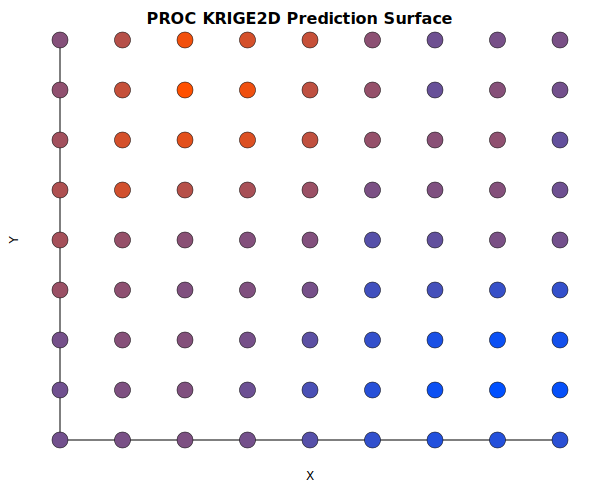

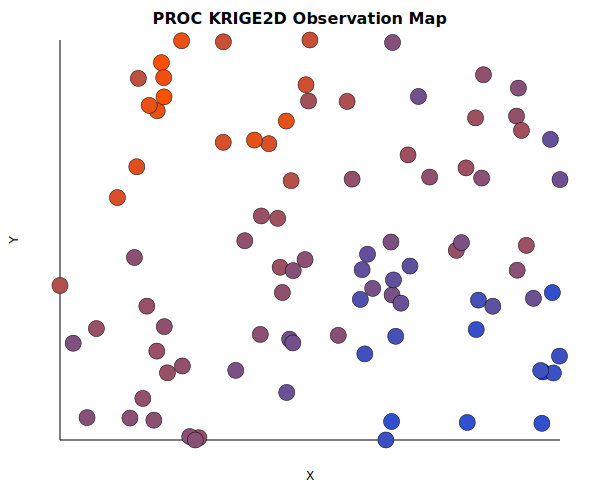

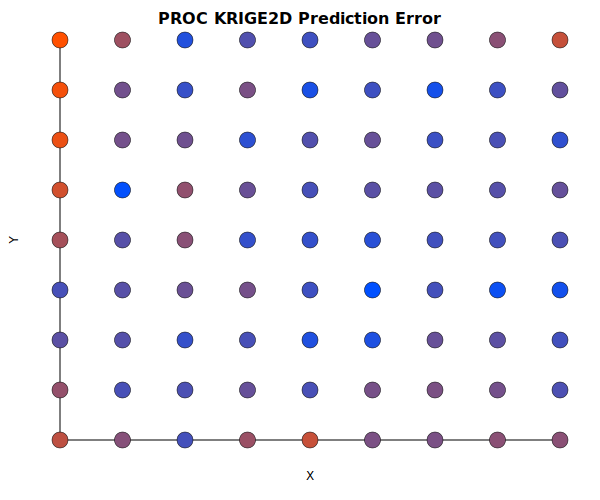

In [3]:
PROCÉDURE krige2d DONNÉES=ed_sites outest=krige_sph outnbhd=nbhd_sph
      PLOTS(only)=(observations prediction(fill=pred line=se));
   TITRE "Krigeage Ordinaire des Temps d'Attente aux Urgences - Modèle Sphérique";
   COORDINATES XC=east YC=north;
   predict VAR=wait_min radius=20 minpoints=10 maxpoints=40;
   MODÈLE FORM=spherical SCALE=120 range=18 NUGGET=14;
   grid x=0 JUSQU_À 50 PAR 6 y=0 JUSQU_À 50 PAR 6;
EXÉCUTER;

## Étape 4 - Inspecter la surface krigée

Le jeu de données `OUTEST=` contient une ligne par nœud de grille avec le temps d'attente prédit (`estimate`) et son erreur type de krigeage (`stderr`). Nous résumons la surface et signalons les nœuds prédits les plus chauds - zones candidates où un nouveau site de soins urgents soulagerait le plus de pression.

La moyenne de la surface krigée (**35,55 minutes**) suit la moyenne observée des établissements (35,5) presque exactement, une vérification de cohérence que le krigeage ordinaire est non biaisé. Les prédictions vont de **16,1** dans le sud-est peu dense à **56,4** dans le nord-ouest congestionné ; les erreurs types vont de **5,1** là où les établissements sont denses à **11,2** dans les coins peu échantillonnés. Les six nœuds les plus chauds se trouvent tous dans le quadrant NO autour de (12-18, 36-48), en plein sur la pointe centre-ville intégrée aux données.

In [4]:
PROCÉDURE MOYENNES DONNÉES=krige_sph n mean MIN MAX maxdec=2;
   TITRE "Récapitulatif de la Surface Krigée (Minutes d'Attente Prédites et Erreur Type)";
   VAR ESTIMATION stderr;
   ÉTIQUETTE ESTIMATION = "Estimation (min)"
         stderr   = "Erreur type";
EXÉCUTER;

PROCÉDURE TRIER DONNÉES=krige_sph out=hot_nodes;
   PAR DESCENDANT ESTIMATION;
EXÉCUTER;

PROCÉDURE IMPRIMER DONNÉES=hot_nodes(obs=6) noobs;
   TITRE "Six Nœuds de Grille avec les Temps d'Attente Prédits les Plus Élevés";
   VAR x y ESTIMATION stderr;
   ÉTIQUETTE x        = "Est (km)"
         y        = "Nord (km)"
         ESTIMATION = "Estimation (min)"
         stderr   = "Erreur type";
EXÉCUTER;

                     Récapitulatif de la Surface Krigée (Minutes d'Attente Prédites et Erreur Type)                     

                                                  The MEANS Procedure

 Variable  Label                   N        Mean     Minimum     Maximum
 -----------------------------------------------------------------------
 ESTIMATE  Estimation (min)       81       35.55       16.07       56.38
 STDERR    Erreur type            81        7.38        5.06       11.20
 -----------------------------------------------------------------------

                          Six Nœuds de Grille avec les Temps d'Attente Prédits les Plus Élevés                          

Est (km)  Nord (km)  Estimation (min)   Erreur type
      12         42     56.3838526129  6.3860887297
      12         48      54.379464215   5.876759721
      18         42       53.81777091  8.0028060667
      12         36     51.9499223116  7.7283024845
      18         36     50.7825137373  6.1546512678
       


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: PROC SORT data=krige_sph

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 81 rows from krige_sph.
NOTE: Wrote hot_nodes (81 rows, 4 columns).
NOTE: PROC SORT statement used.
NOTE: PROC PRINT data=hot_nodes

NOTE: PROC PRINT completed: 6 observations printed, 4 variables


## Étape 5 - Prédire à des sites candidats spécifiques

La planification réseau a trois emplacements de soins urgents proposés. Nous krigeons directement à chaque point en le fournissant comme une grille à un seul nœud (`GRID X=cx TO cx BY 1 Y=cy TO cy BY 1`), donnant aux planificateurs le temps d'attente prédit et son erreur type de krigeage à la coordonnée exacte.

Le candidat proche du centre-ville, **(14, 37)**, renvoie le temps d'attente prédit le plus élevé - **52,2 +/- 7,3 minutes** - confirmant qu'il absorberait la demande des urgences les plus fréquentées. Le candidat sud-est **(32, 12)** se trouve dans le coin suburbain calme à **22,0 +/- 6,2**, et le candidat nord-est **(42, 44)** se situe en milieu de plage à **36,4 +/- 5,9**. Sur le seul temps d'attente prédit, le candidat centre-ville constitue le dossier le mieux étayé pour l'implantation.

In [5]:
PROCÉDURE krige2d DONNÉES=ed_sites outest=cand_dt PLOTS=none;
   TITRE "Candidat A - Centre-Ville (14, 37)";
   COORDINATES XC=east YC=north;
   predict VAR=wait_min radius=20 minpoints=8 maxpoints=40;
   MODÈLE FORM=spherical SCALE=120 range=18 NUGGET=14;
   grid x=14 JUSQU_À 14 PAR 1 y=37 JUSQU_À 37 PAR 1;
EXÉCUTER;

PROCÉDURE krige2d DONNÉES=ed_sites outest=cand_se PLOTS=none;
   TITRE "Candidat B - Banlieue Sud-Est (32, 12)";
   COORDINATES XC=east YC=north;
   predict VAR=wait_min radius=20 minpoints=8 maxpoints=40;
   MODÈLE FORM=spherical SCALE=120 range=18 NUGGET=14;
   grid x=32 JUSQU_À 32 PAR 1 y=12 JUSQU_À 12 PAR 1;
EXÉCUTER;

PROCÉDURE krige2d DONNÉES=ed_sites outest=cand_ne PLOTS=none;
   TITRE "Candidat C - Bordure Nord-Est (42, 44)";
   COORDINATES XC=east YC=north;
   predict VAR=wait_min radius=20 minpoints=8 maxpoints=40;
   MODÈLE FORM=spherical SCALE=120 range=18 NUGGET=14;
   grid x=42 JUSQU_À 42 PAR 1 y=44 JUSQU_À 44 PAR 1;
EXÉCUTER;

DONNÉES candidates;
   DÉFINIR cand_dt cand_se cand_ne;
EXÉCUTER;

PROCÉDURE IMPRIMER DONNÉES=candidates noobs;
   TITRE "Temps d'Attente Prédits pour Trois Sites Candidats de Soins Urgents";
   VAR x y ESTIMATION stderr;
   ÉTIQUETTE x        = "Est (km)"
         y        = "Nord (km)"
         ESTIMATION = "Estimation (min)"
         stderr   = "Erreur type";
EXÉCUTER;

                          Six Nœuds de Grille avec les Temps d'Attente Prédits les Plus Élevés                          

   The KRIGE2D Procedure    
     Model Information      

Item                   Value
-----------------  ---------
Variogram Model    SPHERICAL
Kriging Method      ORDINARY
Observations Used         90
Prediction Points          1

          Kriging Predictions          

       X         Y  Estimate  Std Error
--------  --------  --------  ---------
   14.00     37.00   52.1916     7.2579

                          Six Nœuds de Grille avec les Temps d'Attente Prédits les Plus Élevés                          

   The KRIGE2D Procedure    
     Model Information      

Item                   Value
-----------------  ---------
Variogram Model    SPHERICAL
Kriging Method      ORDINARY
Observations Used         90
Prediction Points          1

          Kriging Predictions          

       X         Y  Estimate  Std Error
--------  --------  --------  ---------
   32


NOTE: PROC KRIGE2D: Two-Dimensional Kriging
NOTE: Using Python scipy version 1.16.3
NOTE: PROC KRIGE2D results written to: ./ods_output/krige2d_results.json
NOTE: Wrote cand_dt (1 rows, 4 columns).
NOTE: PROC KRIGE2D: Two-Dimensional Kriging
NOTE: Using Python scipy version 1.16.3
NOTE: PROC KRIGE2D results written to: ./ods_output/krige2d_results.json
NOTE: Wrote cand_se (1 rows, 4 columns).
NOTE: PROC KRIGE2D: Two-Dimensional Kriging
NOTE: Using Python scipy version 1.16.3
NOTE: PROC KRIGE2D results written to: ./ods_output/krige2d_results.json
NOTE: Wrote cand_ne (1 rows, 4 columns).
NOTE: DATA candidates


NOTE: Read 1 rows from cand_dt.
NOTE: Read 2 rows from cand_se.
NOTE: Read 3 rows from cand_ne.
NOTE: Wrote candidates (3 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=candidates

NOTE: PROC PRINT completed: 3 observations printed, 4 variables


## Interprétation des résultats

- **La surface krigée reproduit la structure de congestion du territoire.** Le modèle de krigeage ordinaire sphérique interpole un champ lissé de temps d'attente dont la moyenne aux nœuds de grille (35,55 min) correspond à la moyenne observée des établissements (35,5 min), avec les temps d'attente prédits les plus élevés - jusqu'à 56,4 minutes - concentrés dans le quadrant NO autour de la pointe centre-ville près de (15, 38) que nous avons intégrée aux données synthétiques. Cette correspondance est une vérification de cohérence que le modèle se comporte correctement.
- **Les erreurs types localisent la confiance.** L'erreur type de krigeage va de 5,1 minutes là où les établissements sont denses à 11,2 dans les coins peu échantillonnés du territoire. Les planificateurs devraient traiter les prédictions dans les zones à `stderr` élevé avec prudence ; ce sont aussi les zones où l'ajout d'un établissement améliorerait le plus la couverture future et la mesure future.
- **Les prédictions ponctuelles appuient les décisions d'implantation.** Kriger directement les trois emplacements candidats transforme la surface en une table actionnable. Le candidat centre-ville (14, 37) affiche le temps d'attente prédit le plus élevé (52,2 min) avec une erreur type modérée (7,3), ce qui en fait le dossier le mieux étayé pour un nouveau site de soins urgents afin de délester les urgences les plus fréquentées ; le candidat suburbain sud-est (32, 12) se trouve dans un coin à faible demande (22,0 min) et le candidat de bordure nord-est (42, 44) est en milieu de plage (36,4 min).

En pratique, les paramètres du semi-variogramme (`SCALE`, `RANGE`, `NUGGET`) seraient estimés empiriquement avec PROC VARIOGRAM puis transmis à KRIGE2D - soit comme valeurs explicites comme montré ici, soit automatiquement via `RESTORE` à partir d'un magasin d'objets VARIOGRAM.